## **Notebook Overview — Baseline (Neutral-Style) Decomposition with Bootstrap**

**Purpose:**
This notebook implements the baseline decomposition that treats a neutral GPT rewrite as the reference style. It splits the observed SES score gap into: (i) content differences when both groups are expressed in the neutral style, (ii) style premia of each group’s original writing relative to that baseline, and (iii) scorer tilt for low-SES essays.

**How to Use:**
- Run Cells 1–4 to load data, build the baseline dataset (original + neutral rewrite), and compute point estimates.
- Run Cells 5–7 to bootstrap confidence intervals (essay-level clusters) and save summary tables.
- The final section plots stacked bars for the new decomposition and a separate figure that highlights the style-premium gap.

**Outputs:**
- `decomp_rows_neutral.csv` --> Row-level data with original scores, neutral scores, style premia, and scorer-tilt terms.
- `summary_df` --> Compact table with baseline decomposition point estimates and bootstrap 95% CIs (saved as .csv and .tex).


### **Cell 1 — Imports & Configuration**

**Purpose:**
- Import all core Python libraries used throughout the notebook.  
- Prepare tools for data handling (`pandas`, `numpy`), model estimation (`pyfixest`), and progress visualization (`tqdm`).  
- Include utilities for parallel computation (`joblib`) and statistical modeling (`statsmodels`).  
- Initialize a global random number generator (`rng`) with a fixed seed to ensure reproducibility of bootstrap samples.


In [33]:
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from joblib import Parallel, delayed
import statsmodels.api as sm
from pyfixest.estimation import feols

# Reproducibility
rng = np.random.default_rng(42)

In [34]:
out_path = "../../output/"

table_out_path = "../../output/tables/"

df_path = "../../data/results/no_desc/no_desc_scored.csv"


### **Cell 2 — Load & Basic Preparation**

**Purpose:**
- Load the scored dataset containing essay-level and rewrite-level information.  
- Sort rows by `essay_id` and `k` so each essay’s rewrites appear sequentially, ensuring consistent ordering for later fixed-effect estimation and bootstrapping.  
- Reset the index to maintain a clean 0–N row index after sorting.


In [35]:
df = pd.read_csv(df_path, encoding="ISO-8859-1", index_col=0)

df = df.sort_values(["essay_id","k"]).reset_index(drop=True)

### **Cell 3 — Build Baseline Dataset (Original + Neutral Rewrite)**

**Purpose:**
- Use the neutral GPT rewrite (`k == 1`) as the reference style.
- Construct a per-essay dataset that keeps original scores from both scorers, the neutral high-scorer score, and derived components (neutral content, style premium, scorer tilt).
- Drop essays without a matching neutral rewrite (grades 9 and 12 are removed for consistency across originals and neutral rewrites).


In [36]:
def build_baseline_decomp_df(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare one row per essay with original scores (both scorers) and the neutral GPT rewrite
    scored by the high-SES scorer. Adds derived columns used in the baseline decomposition.
    """
    df = df_in.copy()

    df_orig = df[df["k"] == 0].copy()
    df_neu = df[df["k"] != 0].copy()

    # Keep essays that have both an original and a neutral rewrite; drop sparse grades
    df_orig = df_orig[~df_orig["grade_level"].isin([9.0, 12.0])]
    df_neu = df_neu[df_neu["essay_id"].isin(df_orig["essay_id"])]

    keep_cols = [
        "essay_id", "low_SES", "race_white", "gender_male",
        "prompt_name", "grade_level", "cv_fold",
        "score_high_full", "score_low_full"
    ]
    df_orig = df_orig[keep_cols].rename(columns={
        "score_high_full": "score_high_orig",
        "score_low_full": "score_low_orig"
    })

    df_neu = df_neu[["essay_id", "score_high_full"]].rename(columns={
        "score_high_full": "score_high_neu"
    })

    out = df_orig.merge(df_neu, on="essay_id", how="inner")

    # Derived components for the baseline decomposition
    out["content_neu"] = out["score_high_neu"]
    out["style_premium"] = out["score_high_orig"] - out["score_high_neu"]
    out["diff_high_low_orig"] = out["score_high_orig"] - out["score_low_orig"]

    # Consistent k flag (all rows correspond to originals)
    out["k"] = 0

    return out


In [37]:
# Define a small utility function to compute conditional means while safely handling missing values (`NaN`).


def mean_mask(s: pd.Series, mask: pd.Series) -> float:
    s2 = s[mask & s.notna()]
    return float(s2.mean()) if len(s2) else np.nan


### **Cell 4 — Decomposition**

**Purpose:**
- Compute the SES gap and its baseline decomposition into **content**, **style premium**, and **scorer tilt**.
- Content: gap in neutral scores under the high-SES scorer (`mu_H^{S(H),neu} − mu_L^{S(H),neu}`).
- Style: difference in style premia relative to neutral (`(mu_H^{S(H),orig}−mu_H^{S(H),neu}) − (mu_L^{S(H),orig}−mu_L^{S(H),neu})`).
- Tilt: scorer-function tilt on low-SES originals (`mu_L^{S(H),orig} − mu_L^{S(L),orig}`).
- Total gap uses the observed scoring pair (`mu_H^{S(H),orig} − mu_L^{S(L),orig}`) so that **total = content + style + tilt**.

**Outputs:**
- Dictionary with absolute gaps: `total_gap`, `content_gap`, `style_gap`, `tilt_gap`.
- Shares: `share_content`, `share_style`, `share_tilt` (component / total_gap).
- `point_est` stores the baseline (non-bootstrap) decomposition for the full sample.


In [38]:
def compute_decomposition_point_estimates(df_in: pd.DataFrame):
    df0 = df_in.copy()

    mH = df0["low_SES"] == 0
    mL = df0["low_SES"] == 1

    # Means under high-scorer
    mu_H_orig = mean_mask(df0["score_high_orig"], mH)
    mu_L_orig_high = mean_mask(df0["score_high_orig"], mL)
    mu_H_neu = mean_mask(df0["score_high_neu"], mH)
    mu_L_neu = mean_mask(df0["score_high_neu"], mL)

    # Low-scorer on low-SES originals
    mu_L_orig_low = mean_mask(df0["score_low_orig"], mL)

    total_gap = mu_H_orig - mu_L_orig_low
    content_gap = mu_H_neu - mu_L_neu
    style_gap = (mu_H_orig - mu_H_neu) - (mu_L_orig_high - mu_L_neu)
    tilt_gap = mu_L_orig_high - mu_L_orig_low

    denom = total_gap if pd.notna(total_gap) and total_gap != 0 else np.nan

    return {
        "total_gap": total_gap,
        "content_gap": content_gap,
        "style_gap": style_gap,
        "tilt_gap": tilt_gap,
        "share_content": content_gap / denom if pd.notna(denom) else np.nan,
        "share_style": style_gap / denom   if pd.notna(denom) else np.nan,
        "share_tilt":  tilt_gap / denom    if pd.notna(denom) else np.nan,
    }


In [39]:
df_baseline = build_baseline_decomp_df(df)
print(f"Baseline dataset size: {len(df_baseline):,} essays (originals matched to neutral rewrites).")

# Save for downstream figures
df_baseline.to_csv(out_path + "decomp_rows_neutral.csv", index=False)
print(f"Saved baseline dataset -> {out_path}decomp_rows_neutral.csv")

point_est = compute_decomposition_point_estimates(df_baseline)
point_est


Baseline dataset size: 121,896 essays (originals matched to neutral rewrites).
Saved baseline dataset -> ../../output/decomp_rows_neutral.csv


{'total_gap': 0.6710275853729422,
 'content_gap': 0.5200734496991499,
 'style_gap': 0.11419630759248367,
 'tilt_gap': 0.03675782808130856,
 'share_content': 0.7750403426561141,
 'share_style': 0.1701812415491323,
 'share_tilt': 0.05477841579475363}

### **Cell 5 — Bootstrap (Clustered at essay_id; Parallelized, 500 Reps, 2.5–97.5% CI)**

**Purpose:**
- Cluster-bootstraps the baseline decomposition at the essay level.
- Each replication resamples essays (with all attached baseline columns), recomputes the decomposition, and stores percentile-based 95% CIs.
- Uses Joblib for parallelization and independent seeds for reproducibility.


In [40]:
B = 500  # number of bootstrap iterations


def run_bootstrap_for_group(df_group: pd.DataFrame, group_label: str, B: int = 500, seed: int = 42):
    """
    Cluster bootstrap for a subset of the baseline dataset (one row per essay).
    """
    df_g = df_group.reset_index(drop=True)
    essay_to_idx_g = df_g.groupby("essay_id").indices
    essay_ids_g = np.array(list(essay_to_idx_g.keys()))
    n_clusters_g = len(essay_ids_g)

    if n_clusters_g < 2:
        print(f"Skipping group {group_label}: only {n_clusters_g} distinct essays.")
        return []

    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=B, dtype=np.uint64)

    def one_rep_group(s: int) -> dict:
        rng_local = np.random.default_rng(s)

        sampled = rng_local.choice(essay_ids_g, size=n_clusters_g, replace=True)
        idx = np.concatenate([essay_to_idx_g[eid] for eid in sampled])
        df_b = df_g.iloc[idx].copy()

        return compute_decomposition_point_estimates(df_b)

    print(f"Running {B} bootstrap iterations for group: {group_label} (N={len(df_g)}, essays={n_clusters_g})")

    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(one_rep_group)(int(s)) for s in tqdm(seeds)
    )

    boot_df_stats = pd.DataFrame(results)

    # --- Compute CIs ---
    ci_bounds = {}
    for col in boot_df_stats.columns:
        low, high = np.nanpercentile(boot_df_stats[col], [2.5, 97.5])
        ci_bounds[col] = (low, high)

    # --- Point estimates on the ORIGINAL (non-resampled) group ---
    point_est = compute_decomposition_point_estimates(df_g)

    # --- Build rows for this group ---
    rows = []
    for stat_name, pe in point_est.items():
        lo, hi = ci_bounds.get(stat_name, (np.nan, np.nan))
        rows.append({
            "group": group_label,
            "stat": stat_name,
            "point_estimate": round(pe, 3),
            "ci_2.5": round(lo, 3),
            "ci_97.5": round(hi, 3),
        })

    return rows


In [41]:
all_rows = []

# Overall
all_rows += run_bootstrap_for_group(df_baseline, "Overall", B=B, seed=42)

# White / Non-White
all_rows += run_bootstrap_for_group(df_baseline[df_baseline["race_white"] == True],  "White",      B=B, seed=101)
all_rows += run_bootstrap_for_group(df_baseline[df_baseline["race_white"] == False], "Non-White",  B=B, seed=102)

# Male / Female
all_rows += run_bootstrap_for_group(df_baseline[df_baseline["gender_male"] == True],  "Male",   B=B, seed=201)
all_rows += run_bootstrap_for_group(df_baseline[df_baseline["gender_male"] == False], "Female", B=B, seed=202)

# All different prompts in prompt_name
for pname in sorted(df_baseline["prompt_name"].dropna().unique()):
    mask = df_baseline["prompt_name"] == pname
    label = f"Prompt={pname}"
    all_rows += run_bootstrap_for_group(df_baseline[mask], label, B=B, seed=300 + hash(pname) % 1000)

# All different grades in grade_level
for g in sorted(df_baseline["grade_level"].dropna().unique()):
    mask = df_baseline["grade_level"] == g
    label = f"Grade={g}"
    all_rows += run_bootstrap_for_group(df_baseline[mask], label, B=B, seed=400 + int(g))

# Final combined table
summary_df = pd.DataFrame(all_rows)
summary_df


Running 500 bootstrap iterations for group: Overall (N=121896, essays=20316)


100%|██████████| 500/500 [01:20<00:00,  6.18it/s]


Running 500 bootstrap iterations for group: White (N=56118, essays=9353)


100%|██████████| 500/500 [00:11<00:00, 43.82it/s]


Running 500 bootstrap iterations for group: Non-White (N=65778, essays=10963)


...

Running 500 bootstrap iterations for group: Grade=10.0 (N=37860, essays=6310)


100%|██████████| 500/500 [00:07<00:00, 64.49it/s]


Running 500 bootstrap iterations for group: Grade=11.0 (N=18492, essays=3082)


100%|██████████| 500/500 [00:04<00:00, 122.22it/s]


,group,stat,point_estimate,ci_2.5,ci_97.5
0,Overall,total_gap,0.671,0.646,0.695
1,Overall,content_gap,0.520,0.496,0.546
2,Overall,style_gap,0.114,0.104,0.123
3,Overall,tilt_gap,0.037,0.032,0.042
4,Overall,share_content,0.775,0.760,0.789
...,...,...,...,...,...
142,Grade=11.0,style_gap,0.176,0.147,0.203
143,Grade=11.0,tilt_gap,0.034,0.021,0.047
144,Grade=11.0,share_content,0.572,0.504,0.631
145,Grade=11.0,share_style,0.358,0.303,0.416


### **Cell 7 — Summary Table (Point Estimates + Bootstrap Confidence Intervals)**

**Purpose:**
- Combine the **baseline decomposition point estimates** (from Cell 5)  
with the **bootstrap confidence intervals** (from Cell 6) into one concise summary table.  

In [42]:
GROUP_LABELS = {
    "All": "All",
    "race_white=True": "White",
    "race_white=False": "Non-White",
    "gender_male=True": "Male",
    "gender_male=False": "Female",
    "Grade=6.0": "Grade 6",
    "Grade=8.0": "Grade 8",
    "Grade=10.0": "Grade 10",
    "Grade=11.0": "Grade 11",
}

# Format estimate + CI into a single compact value
def format_ci(row):
    return f"{row['point_estimate']:.3f} [{row['ci_2.5']:.3f}, {row['ci_97.5']:.3f}]"

summary_df_display = summary_df.copy()

summary_df_display["estimate_ci"] = summary_df_display.apply(format_ci, axis=1)

# Map raw group names to labels
summary_df_display["group"] = summary_df_display["group"].map(
    lambda x: GROUP_LABELS.get(x, x)  # fallback = original (e.g., prompts)
)

visual_table = (
    summary_df_display
    .pivot(index="stat", columns="group", values="estimate_ci")
    .sort_index(axis=1)
)

# -> First: group labels in the exact order defined
ordered_group_names = list(GROUP_LABELS.values())

# -> Then: prompt groups (anything starting with "Prompt")
prompt_cols = sorted([col for col in visual_table.columns if str(col).startswith("Prompt")])

# -> Then: any remaining unexpected groups
other_cols = [
    col for col in visual_table.columns
    if col not in ordered_group_names and col not in prompt_cols
]

# Final column order
final_order = ordered_group_names + prompt_cols + other_cols
final_order = [col for col in final_order if col in visual_table.columns]

visual_table = visual_table[final_order]


visual_table = (
    visual_table
    .rename_axis(index=None, columns=None)  # drop 'stat' and 'group' axis names
)

visual_table.columns


Index(['White', 'Non-White', 'Male', 'Female', 'Grade 6', 'Grade 8',
       'Grade 10', 'Grade 11', 'Prompt="A Cowboy Who Rode the Waves"',
       'Prompt=Cell phones at school', 'Prompt=Community service',
       'Prompt=Distance learning', 'Prompt=Driverless cars',
       'Prompt=Exploring Venus', 'Prompt=Facial action coding system',
       'Prompt=Grades for extracurricular activities',
       'Prompt=Mandatory extracurricular activities',
       'Prompt=Seeking multiple opinions', 'Prompt=Summer projects',
       'Prompt=The Face on Mars', 'Overall'],
      dtype='object')

In [43]:
col_list = ['White', 'Non-White', 'Male', 'Female', 'Grade 6', 'Grade 8',
       'Grade 10', 'Grade 11', 'Overall']

prompt_cols = [c for c in visual_table.columns if str(c).startswith("Prompt")]

In [44]:
# Full table (already computed)
full_table = visual_table.copy()

# Demographics-only table
demo_table = visual_table[col_list].copy()

# Prompts-only table
prompt_table = visual_table[prompt_cols].copy()

In [45]:
# === Save FULL table ===
full_table.to_csv(
    table_out_path + "decomposition_bootstrap_summary_full.csv"
)
full_table.to_latex(
    table_out_path + "decomposition_bootstrap_summary_full.tex",
    escape=False
)

# === Save DEMOGRAPHICS-ONLY table ===
demo_table.to_csv(
    table_out_path + "decomposition_bootstrap_summary_demographics.csv"
)
demo_table.to_latex(
    table_out_path + "decomposition_bootstrap_summary_demographics.tex",
    escape=False
)

# === Save PROMPTS-ONLY table ===
prompt_table.to_csv(
    table_out_path + "decomposition_bootstrap_summary_prompts.csv"
)
prompt_table.to_latex(
    table_out_path + "decomposition_bootstrap_summary_prompts.tex",
    escape=False
)

# Decomposition Figures 

In [46]:

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl


In [47]:
df_decomp = pd.read_csv(out_path + "decomp_rows_neutral.csv")
FIG_SIZE = (12,6)
SAVE_DIR = "../../output/"


In [48]:
COMP_ORDER = ["content", "style", "tilt"]
COMP_COLORS = {"content": "#84C7F9", "style": "#C7B6F7", "tilt": "#B6E3C7"}

# ---------- Core: compute shares ----------
def _mean_mask(s, mask):
    s2 = s[mask & s.notna()]
    return float(s2.mean()) if len(s2) else np.nan


def _compute_decomp(df_sub):
    mH = df_sub["low_SES"] == 0
    mL = df_sub["low_SES"] == 1
    if not (mH.any() and mL.any()):
        return pd.Series({c: np.nan for c in COMP_ORDER})

    mu_H_orig = _mean_mask(df_sub["score_high_orig"], mH)
    mu_L_orig_high = _mean_mask(df_sub["score_high_orig"], mL)
    mu_L_orig_low = _mean_mask(df_sub["score_low_orig"], mL)

    mu_H_neu = _mean_mask(df_sub["score_high_neu"], mH)
    mu_L_neu = _mean_mask(df_sub["score_high_neu"], mL)

    total_gap = mu_H_orig - mu_L_orig_low
    if not total_gap:
        return pd.Series({c: np.nan for c in COMP_ORDER})

    content_gap = mu_H_neu - mu_L_neu
    style_gap   = _mean_mask(df_sub["style_premium"], mH) - _mean_mask(df_sub["style_premium"], mL)
    tilt_gap    = _mean_mask(df_sub["diff_high_low_orig"], mL)

    return pd.Series({
        "content": content_gap / total_gap,
        "style":   style_gap   / total_gap,
        "tilt":    tilt_gap    / total_gap
    })

# ---------- Add grade_level to compute_decomp_shares ----------
def compute_decomp_shares(df_decomp):
    df = df_decomp.copy()

    groups = {"All": df}

    # by race / gender
    for g in ["race_white", "gender_male"]:
        if g in df.columns:
            groups[f"{g}=True"]  = df[df[g] == True]
            groups[f"{g}=False"] = df[df[g] == False]

    # by grade_level (NEW)
    if "grade_level" in df.columns:
        for gl in sorted(df["grade_level"].dropna().unique()):
            groups[f"grade_level={gl}"] = df[df["grade_level"] == gl]

    # by prompt
    if "prompt_name" in df.columns:
        for p in sorted(df["prompt_name"].dropna().unique()):
            groups[f"Prompt: {p}"] = df[df["prompt_name"] == p]

    out = pd.DataFrame({k: _compute_decomp(v) for k, v in groups.items()}).T
    return out.reindex(columns=COMP_ORDER)


# ---------- Plot helpers ----------
def plot_stacked(df_shares, title=None, figsize=(10,6), xtick_rotation=0, save_path=None, label_map=None):
    """
    Draw stacked bar chart of decomposition shares with nicer labels.
    """
    if df_shares.empty:
        print("No data to plot.")
        return

    # Apply mapping for nicer labels (default: GROUP_LABELS)
    if label_map is None:
        label_map = GROUP_LABELS
    df_plot = df_shares.copy()
    df_plot.index = df_plot.index.map(lambda x: label_map.get(x, x))

    ax = df_plot[COMP_ORDER].plot(
        kind="bar",
        stacked=True,
        color=[COMP_COLORS[c] for c in COMP_ORDER],
        edgecolor="white",
        linewidth=0.6,
        figsize=figsize
    )
    ax.set_ylabel("Share of Total SES Gap")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.axhline(1, color="gray", lw=0.8, linestyle="--")
    if title:
        ax.set_title(title, pad=10)
    plt.xticks(rotation=xtick_rotation, ha="right" if xtick_rotation else "center")

    ax.legend(
        title="Component",
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path,  bbox_inches="tight")
    plt.show()


def plot_overview(decomp_shares, save_path=None, label_map=None):
    base = ["All", "race_white=True", "race_white=False", "gender_male=True", "gender_male=False"]
    grade_keys = sorted([i for i in decomp_shares.index if i.startswith("grade_level=")],key=lambda x: float(x.split("=")[1]))
    want = base + grade_keys  
    overview = decomp_shares.reindex(want).dropna(how="all")
    plot_stacked(overview, figsize=FIG_SIZE, xtick_rotation=45, save_path=save_path, label_map=label_map)


def plot_prompts(decomp_shares, save_path=None, label_map=None, figsize=(10,6)):
    prompts = decomp_shares.loc[decomp_shares.index.str.startswith("Prompt: ")].sort_index()
    h = max(5, 0.45 * len(prompts))
    plot_stacked(prompts, figsize=figsize, xtick_rotation=45, save_path=save_path, label_map=label_map)


In [49]:
# ---------- Group label mapping ----------
GROUP_LABELS = {
    "All": "All",
    "race_white=True": "White",
    "race_white=False": "Non-White",
    "gender_male=True": "Male",
    "gender_male=False": "Female",
    "grade_level=6.0": "Grade 6",
    "grade_level=8.0": "Grade 8",
    "grade_level=10.0": "Grade 10",
    "grade_level=11.0": "Grade 11",
}


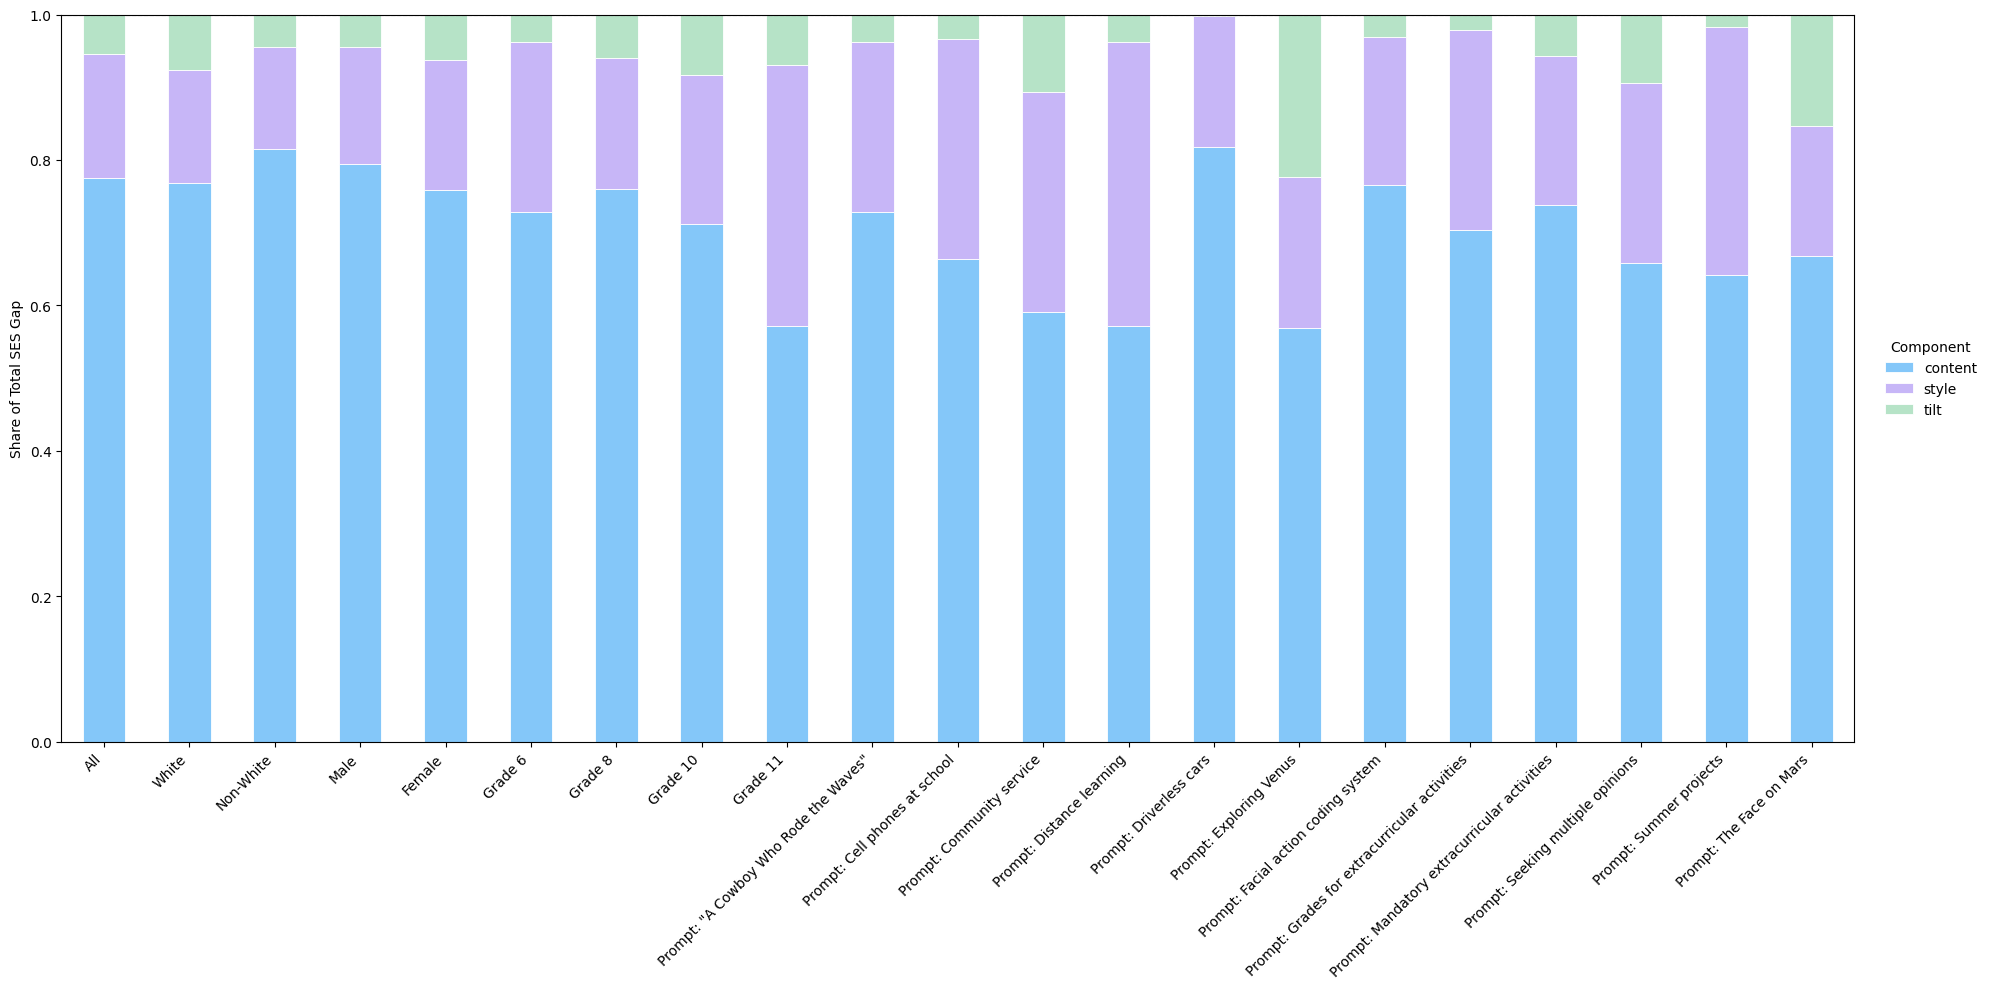

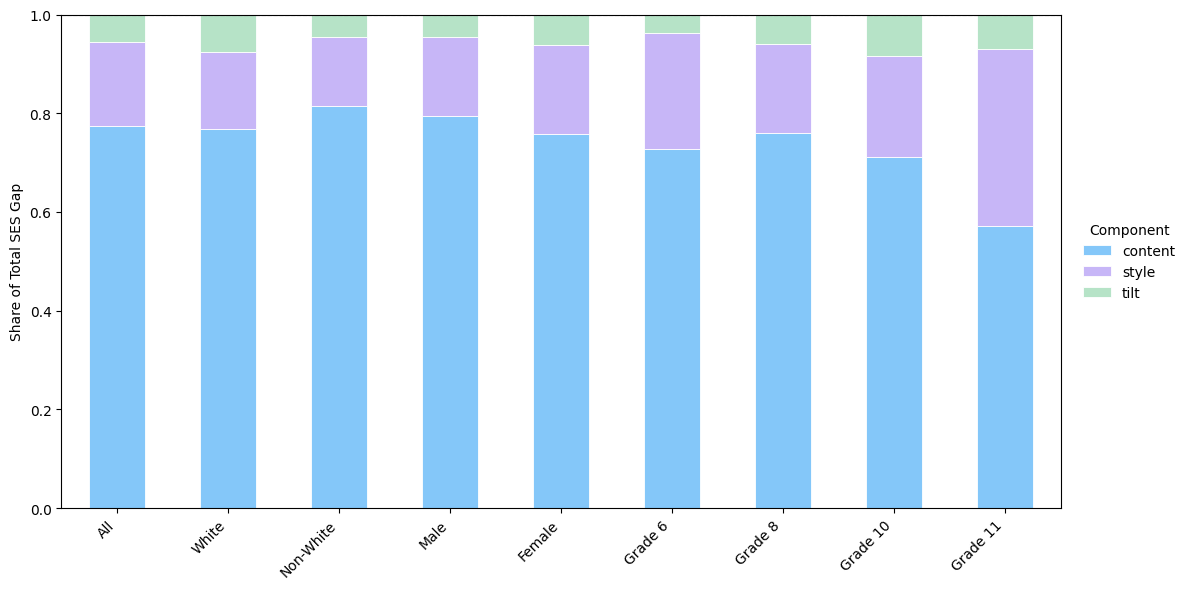

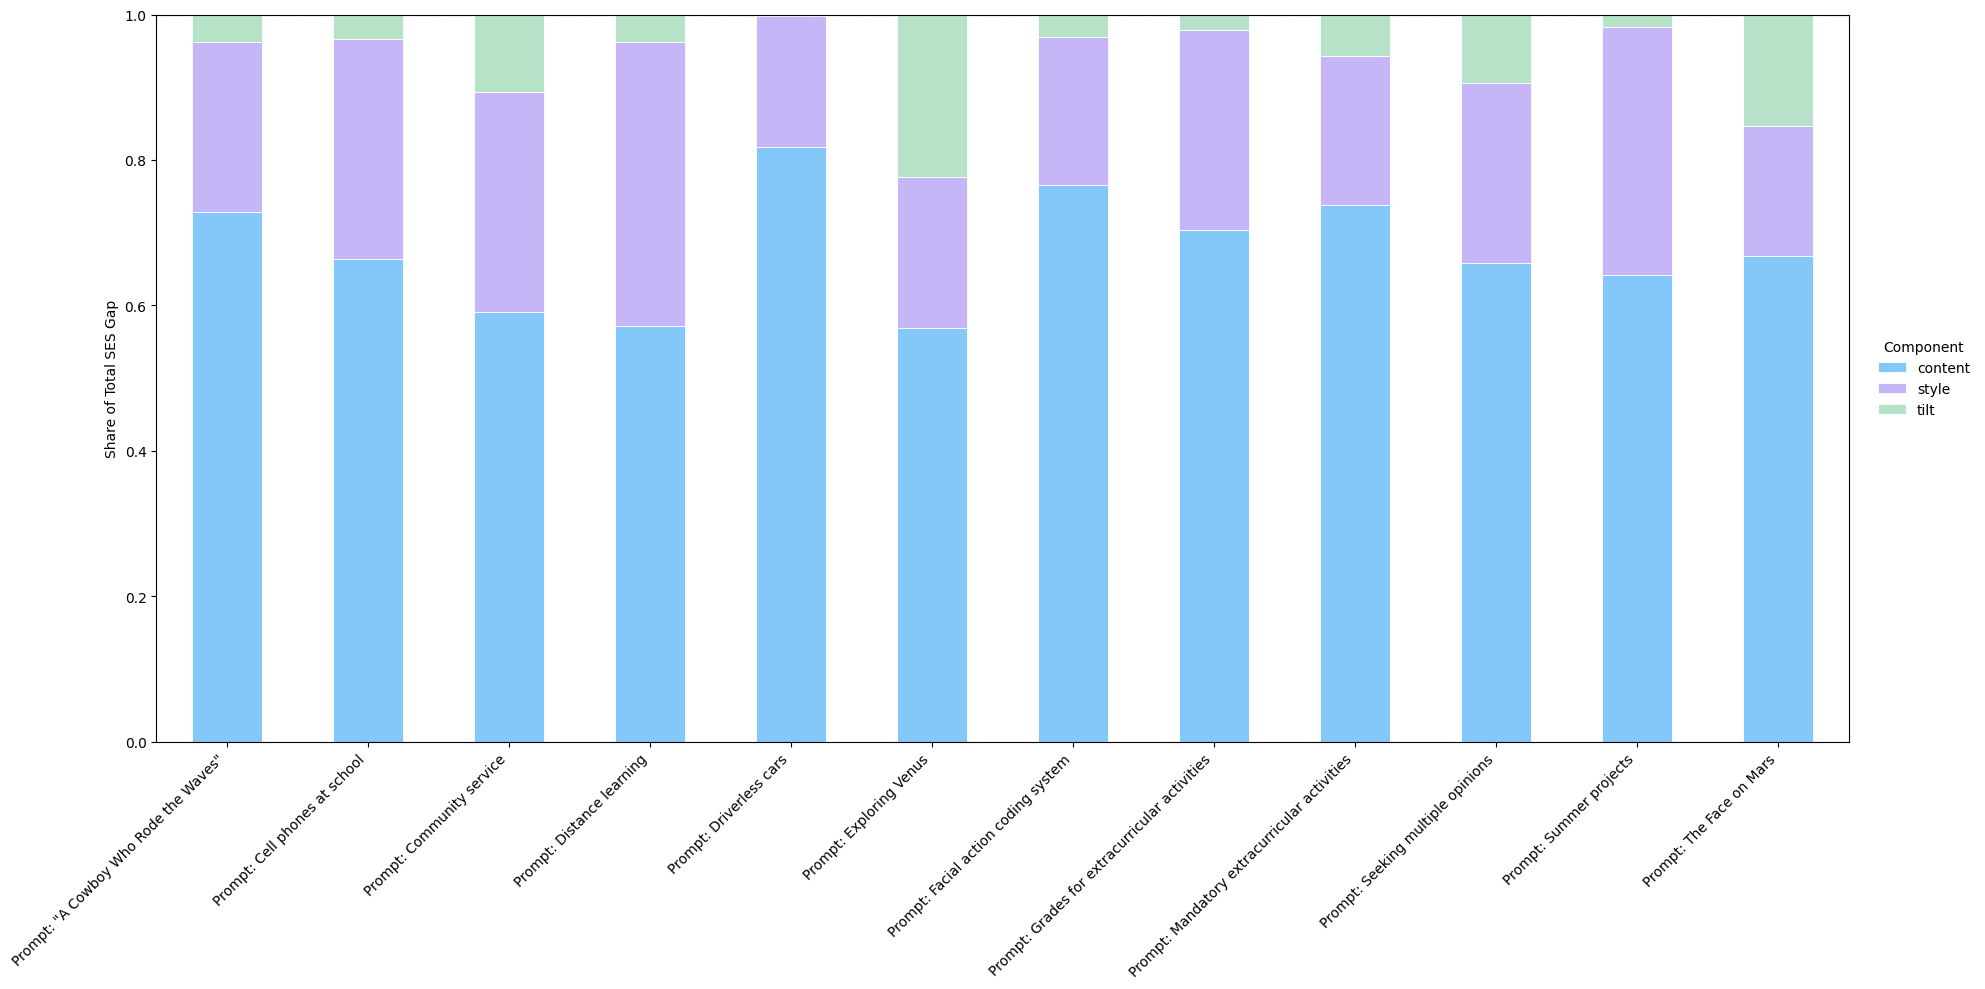

In [50]:
decomp_shares = compute_decomp_shares(df_decomp)

plot_stacked(
    decomp_shares,
    figsize=(20,10),
    xtick_rotation=45,
    save_path=f"{SAVE_DIR}decomp_shares_all.pdf",
    label_map=GROUP_LABELS
)

plot_overview(
    decomp_shares,
    save_path=f"{SAVE_DIR}decomp_shares_overview.pdf",
    label_map=GROUP_LABELS
)

plot_prompts(
    decomp_shares,
    figsize=(20,10),
    save_path=f"{SAVE_DIR}decomp_shares_prompts.pdf",
    label_map=GROUP_LABELS
)


### **Style Premium by Group and SES**

Shows the style premium (orig − neutral under the high-SES scorer) separately for high-SES and low-SES writers, across the full sample, demographics, and grades. Bars are side-by-side with 95% CI error bars (mean ± 1.96·SE).

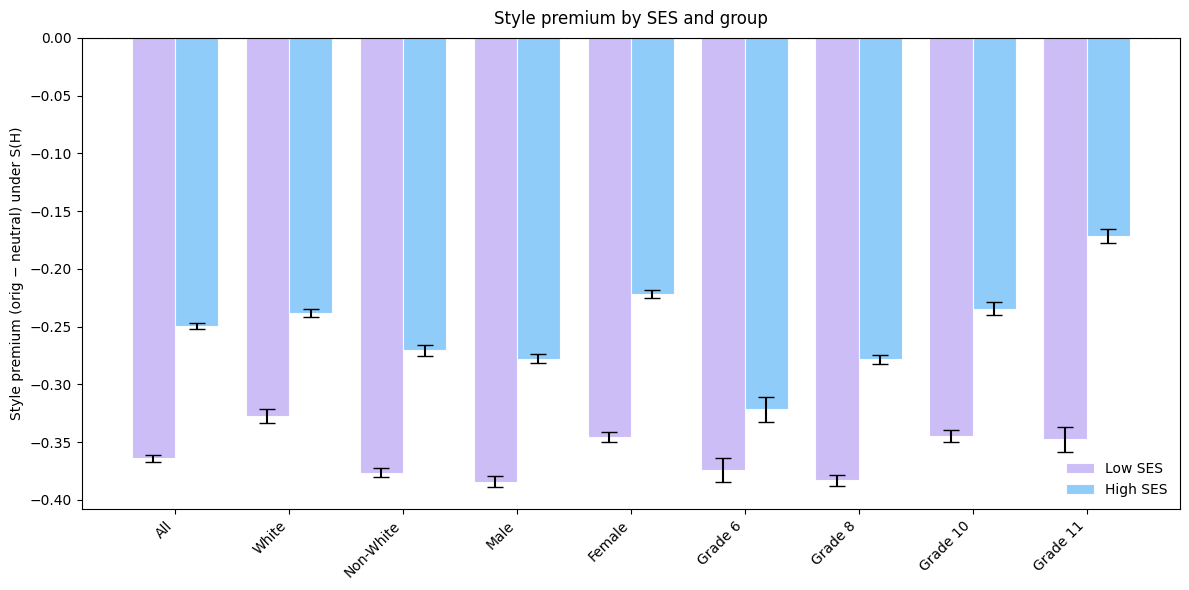

In [51]:
def compute_style_premium_levels(df_in: pd.DataFrame):
    groups = {"All": df_in}
    for g in ["race_white", "gender_male"]:
        if g in df_in.columns:
            groups[f"{g}=True"] = df_in[df_in[g] == True]
            groups[f"{g}=False"] = df_in[df_in[g] == False]
    if "grade_level" in df_in.columns:
        for gl in sorted(df_in["grade_level"].dropna().unique()):
            groups[f"grade_level={gl}"] = df_in[df_in["grade_level"] == gl]

    rows = []
    for name, sub in groups.items():
        sub = sub[sub["style_premium"].notna()]
        high = sub[sub["low_SES"] == 0]["style_premium"].astype(float)
        low = sub[sub["low_SES"] == 1]["style_premium"].astype(float)
        if len(high) == 0 or len(low) == 0:
            continue
        rows.append({
            "group": name,
            "mean_high": high.mean(),
            "se_high": high.std(ddof=1) / np.sqrt(len(high)),
            "mean_low": low.mean(),
            "se_low": low.std(ddof=1) / np.sqrt(len(low)),
            "n_high": len(high),
            "n_low": len(low),
        })

    return pd.DataFrame(rows)


def plot_style_premium_levels(df_stats, save_path=None, label_map=None):
    if df_stats.empty:
        print("No style premium data to plot.")
        return

    if label_map is None:
        label_map = GROUP_LABELS

    base_order = [
        "All",
        "race_white=True", "race_white=False",
        "gender_male=True", "gender_male=False",
    ]
    grade_keys = sorted([g for g in df_stats["group"] if g.startswith("grade_level=")], key=lambda x: float(x.split("=")[1]))
    order_map = {g: i for i, g in enumerate(base_order + grade_keys)}
    default_start = len(order_map)

    df_plot = df_stats.copy()
    df_plot["order"] = [order_map.get(g, default_start + i) for i, g in enumerate(df_plot["group"])]
    df_plot = df_plot.sort_values("order")
    df_plot["label"] = df_plot["group"].map(lambda x: label_map.get(x, x))

    x = np.arange(len(df_plot))
    width = 0.38

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(
        x - width/2,
        df_plot["mean_low"],
        yerr=1.96 * df_plot["se_low"],
        width=width,
        color=COMP_COLORS.get("style", "#C7B6F7"),
        edgecolor="white",
        linewidth=0.8,
        capsize=6,
        alpha=0.9,
        label="Low SES"
    )
    ax.bar(
        x + width/2,
        df_plot["mean_high"],
        yerr=1.96 * df_plot["se_high"],
        width=width,
        color=COMP_COLORS.get("content", "#84C7F9"),
        edgecolor="white",
        linewidth=0.8,
        capsize=6,
        alpha=0.9,
        label="High SES"
    )

    ax.axhline(0, color="gray", lw=0.8, linestyle="--")
    ax.set_ylabel("Style premium (orig − neutral) under S(H)")
    ax.set_xlabel("")
    ax.set_title("Style premium by SES and group", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["label"], rotation=45, ha="right")
    ax.legend(frameon=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


style_premium_levels = compute_style_premium_levels(df_decomp)
plot_style_premium_levels(
    style_premium_levels,
    save_path=f"{SAVE_DIR}style_premium_levels_by_group.pdf",
    label_map=GROUP_LABELS
)
